# Predicting Next-Day PM2.5 Concentration in Delhi

## Introduction

Air pollution is a significant public health issue in Delhi, India.  
Particulate Matter (PM2.5) is a hazardous air pollutant that can penetrate deep into the lungs and bloodstream, causing respiratory and cardiovascular problems.  
Accurate short-term forecasts of PM2.5 levels can help policymakers, health agencies, and individuals make informed decisions to protect health.

In this project, we build a simple and interpretable data science pipeline to forecast the **next-day PM2.5 concentration** (t+1) in Delhi using historical air quality and meteorological data.

We focus on:

- Data cleaning and preprocessing
- Feature engineering
- Regression modeling with interpretable models
- Proper evaluation using time-series split and baseline
- Interpretation of model behavior

## Problem Statement

Given the pollutant and weather conditions at day `t`, predict the PM2.5 concentration at day `t+1`.  
This is a next-day forecasting task using supervised regression.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")

pd.set_option('display.max_columns', None)

## Dataset and preprocessing

We use an hourly air quality and weather dataset for the Anand Vihar monitoring station in Delhi containing PM2.5 and meteorological variables.
The data are aggregated to a daily time scale before modelling.

The final dataset contains daily PM2.5, temperature, humidity and wind speed.

In [2]:
df_raw = pd.read_csv(
    "/kaggle/input/delhi-weather-and-aqi-dataset-2025/delhi-weather-aqi-2025.csv"
)

df_raw.head()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6


In [3]:
df = df_raw.copy()

df["date_ist"] = pd.to_datetime(df["date_ist"], errors="coerce")

daily_df = (
    df.groupby(df["date_ist"].dt.date)
    .agg(
        pm25=("pm2_5", "mean"),
        temperature=("temp_c", "mean"),
        humidity=("humidity", "mean"),
        windspeed=("windspeed_kph", "mean")
    )
    .reset_index()
)

daily_df["date"] = pd.to_datetime(daily_df["date_ist"])
daily_df = daily_df.drop(columns="date_ist")

daily_df = daily_df.sort_values("date").reset_index(drop=True)

daily_df.head()

,pm25,temperature,humidity,windspeed,date
0,144.972917,10.920833,89.416667,5.763889,2025-01-01
1,100.314583,18.622917,66.145833,6.045833,2025-01-02
2,54.570833,19.462500,81.472222,7.261806,2025-01-03
3,101.693750,26.470139,20.236111,8.342361,2025-01-04
4,142.583333,31.680556,37.659722,9.870833,2025-01-05


The hourly observations are aggregated to daily averages and aligned into a single daily time series.

## Feature construction

We construct lagged and rolling features using only information available up to the current day.

The target variable is defined as the PM2.5 concentration on the following day (t+1).

In [4]:
df_feat = daily_df.copy()

df_feat["pm25_lag1"] = df_feat["pm25"].shift(1)

df_feat["pm25_7d_avg"] = (
    df_feat["pm25"]
    .rolling(window=7)
    .mean()
    .shift(1)
)

df_feat["target_pm25"] = df_feat["pm25"].shift(-1)

df_feat = df_feat.dropna().reset_index(drop=True)

features = [
    "pm25_lag1",
    "pm25_7d_avg",
    "temperature",
    "humidity",
    "windspeed"
]

X = df_feat[features]
y = df_feat["target_pm25"]

X.head()

,pm25_lag1,pm25_7d_avg,temperature,humidity,windspeed
0,44.535417,100.303571,28.327083,85.305556,4.512500
1,49.104167,86.608036,25.658333,91.444444,10.911111
2,20.725000,75.238095,28.231250,76.319444,3.950694
3,43.966667,73.723214,24.795833,63.340278,6.290972
4,95.275000,72.806250,16.300000,53.465278,3.538194


All features are constructed using past or current information only, ensuring that no future data are used in prediction.

## Exploratory data analysis

We first examine the temporal behaviour of PM2.5 and the relationships between the constructed features and the target variable.

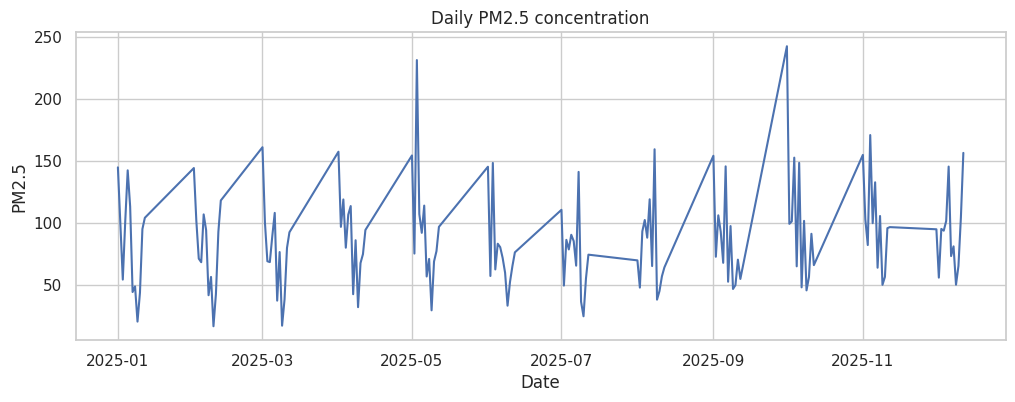

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(daily_df["date"], daily_df["pm25"])
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.title("Daily PM2.5 concentration")
plt.show()

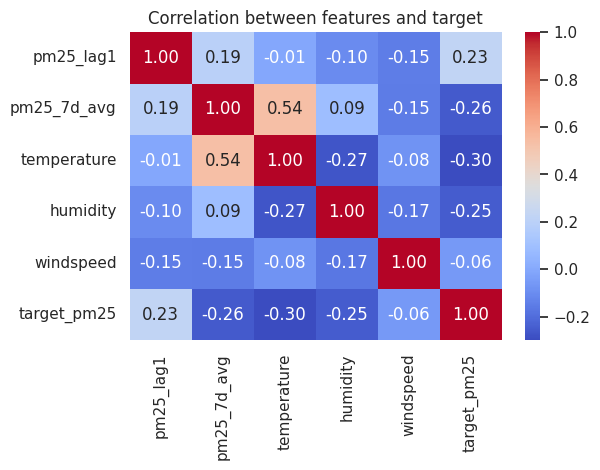

In [6]:
eda_df = df_feat[features + ["target_pm25"]]

plt.figure(figsize=(6, 4))
sns.heatmap(eda_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between features and target")
plt.show()

PM2.5 shows clear temporal persistence, with strong correlations between the next-day PM2.5 and both the previous-day concentration and the 7-day rolling average.  
Meteorological variables exhibit weaker but non-negligible relationships with the target.

## Model building

We use a chronological train–test split, with the first 80% of the observations used for training and the remaining 20% used for testing.

Two regression models are trained:

- Linear Regression
- Random Forest Regressor

In [7]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
y_pred_baseline = X_test["pm25_lag1"]

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [10]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Evaluation

We evaluate all models on the held-out test set using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).
The naive persistence forecast is used as a baseline.

In [11]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


mae_base, rmse_base = evaluate(y_test, y_pred_baseline)
mae_lr, rmse_lr = evaluate(y_test, y_pred_lr)
mae_rf, rmse_rf = evaluate(y_test, y_pred_rf)

results = pd.DataFrame({
    "Model": ["Naive baseline", "Linear Regression", "Random Forest"],
    "MAE": [mae_base, mae_lr, mae_rf],
    "RMSE": [rmse_base, rmse_lr, rmse_rf]
})

results

,Model,MAE,RMSE
0,Naive baseline,36.621131,43.227192
1,Linear Regression,21.611613,29.984697
2,Random Forest,20.796094,29.874331


The naive baseline provides a strong reference due to the persistence of PM2.5 levels.
Both regression models improve upon the baseline, with the random forest achieving the lowest prediction error.
This indicates that incorporating recent pollution history together with meteorological variables improves next-day PM2.5 forecasts.

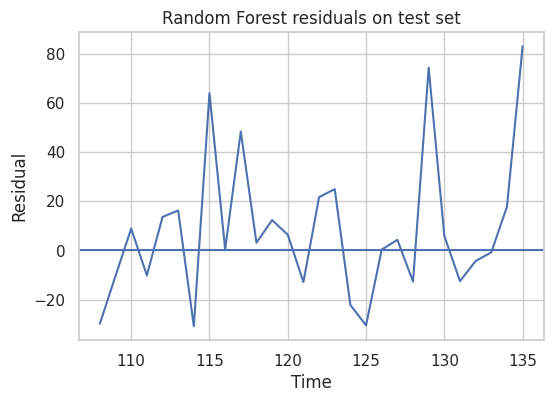

In [12]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(6,4))
plt.plot(y_test.index, residuals)
plt.axhline(0)
plt.title("Random Forest residuals on test set")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

The residuals do not exhibit strong systematic temporal structure, suggesting that the model captures the main short-term dynamics present in the data.

## Interpretation

We examine the contribution of individual features to the predictions using the linear regression coefficients and the random forest feature importances.

In [13]:
coef_df = pd.DataFrame(
    {
        "feature": features,
        "coefficient": lr.coef_
    }
).sort_values("coefficient", key=np.abs, ascending=False)

coef_df

,feature,coefficient
4,windspeed,-2.223402
2,temperature,-2.172757
3,humidity,-0.631495
1,pm25_7d_avg,-0.294669
0,pm25_lag1,0.188752


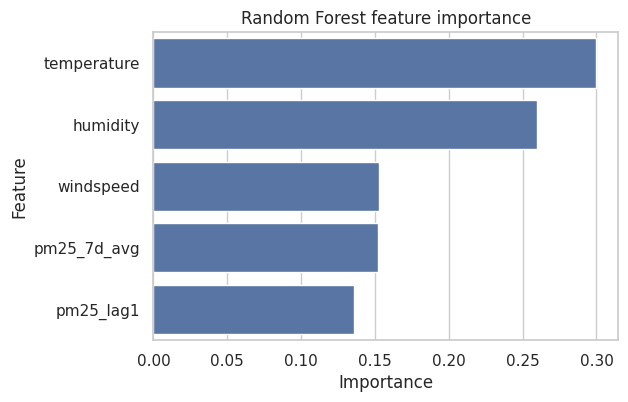

In [14]:
importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=importances.values, y=importances.index)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest feature importance")
plt.show()

The random forest model assigns the highest importance to temperature, followed by humidity and wind speed.
Lagged and rolling PM2.5 features remain important but appear less dominant, likely due to strong collinearity between the persistence-based predictors.

## Limitations and next steps

This study uses a short time span and a limited set of meteorological variables, which restricts the ability of the models to capture seasonal patterns and complex atmospheric processes.

The models also rely on simple daily averages and do not incorporate important drivers such as wind direction, boundary layer height, traffic emissions, industrial activity, or regional transport of pollutants.

Future work could extend this pipeline by including additional meteorological and emission-related variables, using longer historical records, and exploring multi-day forecasting horizons.